In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [3]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [4]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1 + The One Additional Layer
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Your one allowed additional layer [cite: 23]

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Use ReLU in the beginning to "wake up" the gradients
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        # Transition back to Sigmoid for the deeper layers if you prefer
        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

In [5]:

# 6. Initialize Network
model = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [7]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    train_f1 = f1_score(all_labels, all_preds, average="macro")



    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, train_f1, gradient_norms


In [9]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    test_f1 = f1_score(all_labels, all_preds, average="macro")



    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, test_f1


In [10]:
from torch.utils.data import Dataset, ConcatDataset

class AugmentedDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# 1. Define Augmentation Pipeline
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Create the doubled Training set (100,000 images)
original_train = train_dataset # 50k
augmented_train = AugmentedDataset(train_dataset, transform=train_transform) # 50k
full_train_dataset = ConcatDataset([original_train, augmented_train])

# 3. Create the doubled Test set (20,000 images)
original_test = test_dataset # 10k
augmented_test = AugmentedDataset(test_dataset, transform=train_transform) # 10k
full_test_dataset = ConcatDataset([original_test, augmented_test])

# 4. Initialize Loaders
train_loader_aug = DataLoader(full_train_dataset, batch_size=128, shuffle=True)
test_loader_aug = DataLoader(full_test_dataset, batch_size=128, shuffle=False)

print(f"Total Training Images: {len(full_train_dataset)}")
print(f"Total Test Images: {len(full_test_dataset)}")

Total Training Images: 100000
Total Test Images: 20000


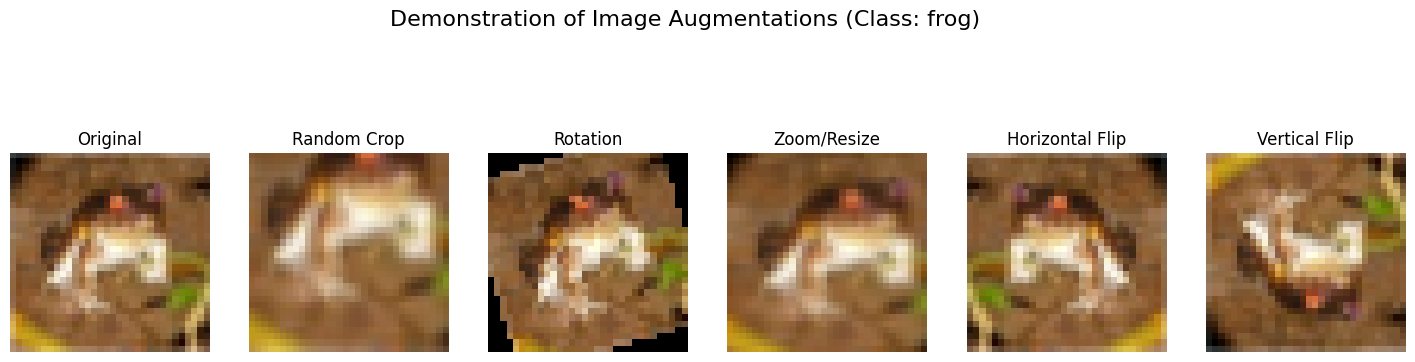

In [11]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch

# Define the specific augmentations requested
augmentations = {
    "Original": transforms.Compose([transforms.ToTensor()]),
    "Random Crop": transforms.Compose([transforms.RandomCrop(24), transforms.Resize(32), transforms.ToTensor()]),
    "Rotation": transforms.Compose([transforms.RandomRotation(30), transforms.ToTensor()]),
    "Zoom/Resize": transforms.Compose([transforms.RandomResizedCrop(32, scale=(0.5, 0.9)), transforms.ToTensor()]),
    "Horizontal Flip": transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),
    "Vertical Flip": transforms.Compose([transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor()])
}

# Function to visualize transformations
def visualize_augmentations(dataset, index=0):
    img_pil, label = dataset.data[index], dataset.targets[index]
    img_pil = Image.fromarray(img_pil)
    
    fig, axes = plt.subplots(1, 6, figsize=(18, 5))
    fig.suptitle(f"Demonstration of Image Augmentations (Class: {dataset.classes[label]})", fontsize=16)
    
    for i, (name, tf) in enumerate(augmentations.items()):
        augmented_img = tf(img_pil).permute(1, 2, 0)
        axes[i].imshow(augmented_img)
        axes[i].set_title(name)
        axes[i].axis('off')
    plt.show()

# Run visualization on the first image
visualize_augmentations(train_dataset, index=0)

In [12]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []
train_f1s = []
test_f1s = []
all_epoch_gradient_norms = []

for epoch in range(num_epochs):

    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader_aug)
    test_loss, test_acc, test_f1 = test(model, test_loader_aug)

    # 2. Storage
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    # 3. Process Gradients (Fixed variable name here)
    epoch_grad_averages = {}
    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)
    
    all_epoch_gradient_norms.append(epoch_grad_averages)
    
    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    # --- ADDED: Print Gradient Magnitudes ---
    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        # Using :.6f because these numbers might be very small!
        print(f"  {layer}: {magnitude:.6f}")



    print("-" * 40)
    

Epoch 1/15
Train Loss: 1.8862 | Test Loss: 1.6025
Train Accuracy: 28.37% | Test Accuracy: 40.87%
Train F1: 0.2769 | Test F1: 0.3902
Average Gradient Magnitudes:
  conv1.weight: 0.738921
  conv1.bias: 0.000006
  bn1.weight: 0.172556
  bn1.bias: 0.188002
  conv2.weight: 0.635709
  conv2.bias: 0.055427
  conv3.weight: 0.148773
  conv3.bias: 0.007767
  conv4.weight: 0.079909
  conv4.bias: 0.008293
  fc1.weight: 0.088626
  fc1.bias: 0.012913
  fc2.weight: 0.717560
  fc2.bias: 0.094827
----------------------------------------
Epoch 2/15
Train Loss: 1.4563 | Test Loss: 1.3846
Train Accuracy: 47.00% | Test Accuracy: 49.60%
Train F1: 0.4642 | Test F1: 0.4908
Average Gradient Magnitudes:
  conv1.weight: 1.119910
  conv1.bias: 0.000011
  bn1.weight: 0.205958
  bn1.bias: 0.251411
  conv2.weight: 0.963471
  conv2.bias: 0.089167
  conv3.weight: 0.342581
  conv3.bias: 0.018095
  conv4.weight: 0.203816
  conv4.bias: 0.018191
  fc1.weight: 0.131093
  fc1.bias: 0.017375
  fc2.weight: 0.652184
  fc2.bias

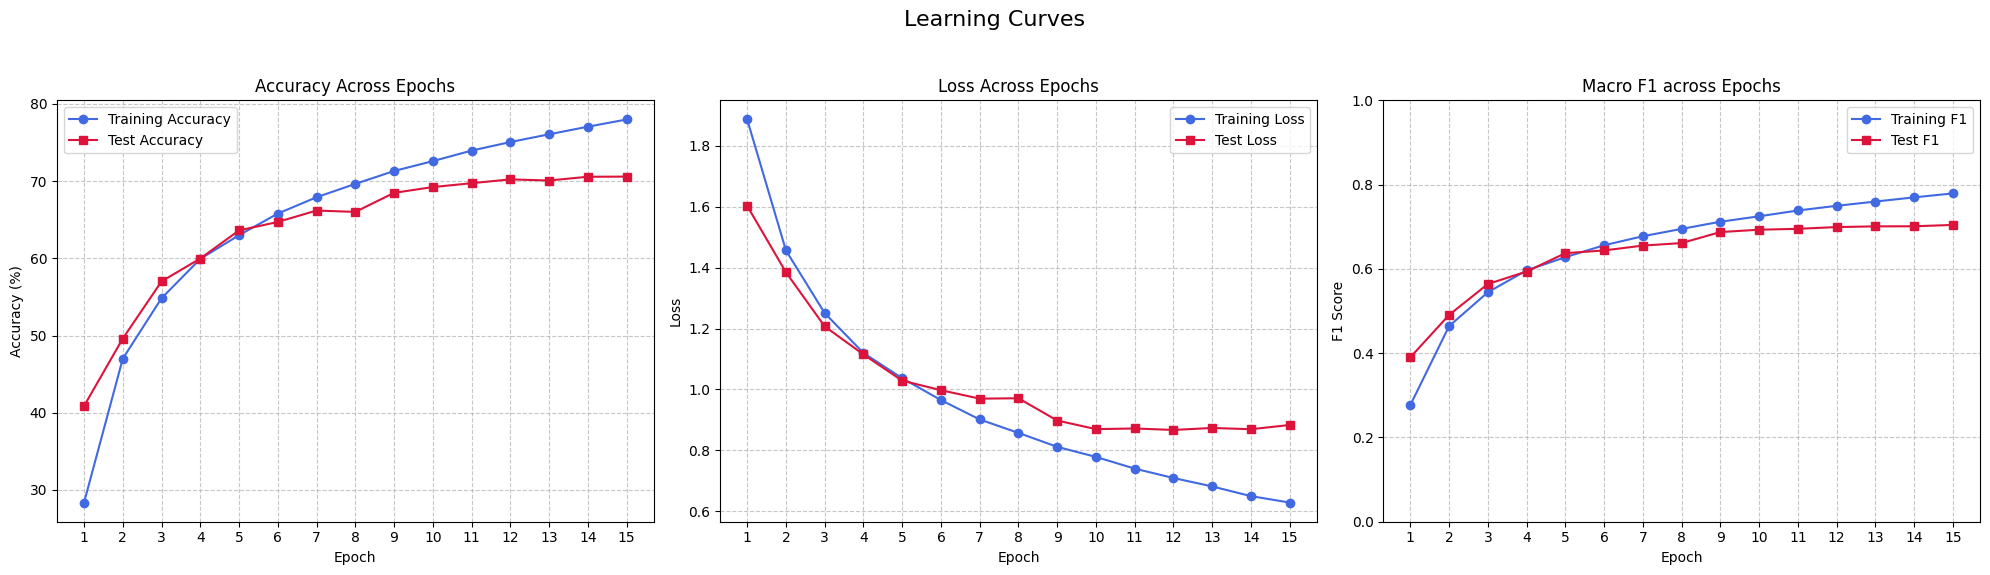

In [14]:
import matplotlib.pyplot as plt

# Define the epoch range (1 to 15)
epochs = range(1, num_epochs + 1)

# Create the main figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves', fontsize=16) # Set the name of the whole figure

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs) # Ensure axis shows every epoch from 1 to 15
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs) # Ensure axis shows every epoch from 1 to 15
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('Macro F1 across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

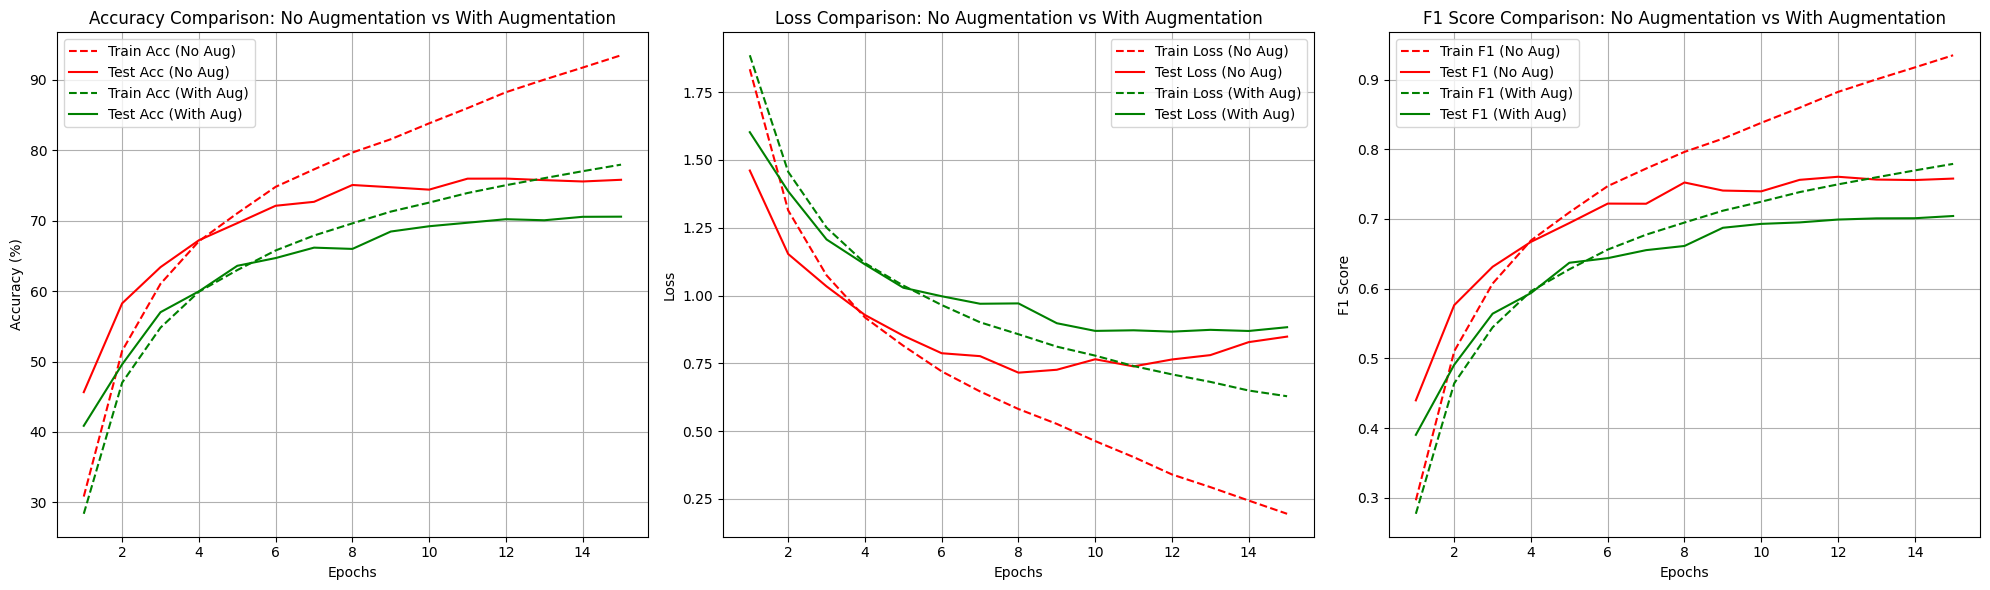

In [25]:
import matplotlib.pyplot as plt

# Data from your "Without Augmentation" run (The Improved CNN)
# =========================
# Without Augmentation
# =========================

train_acc_no_aug = [
    30.82, 51.52, 61.04, 67.09, 71.06,
    74.82, 77.30, 79.69, 81.58, 83.84,
    86.00, 88.26, 90.05, 91.76, 93.51
]

test_acc_no_aug = [
    45.65, 58.27, 63.41, 67.23, 69.66,
    72.13, 72.69, 75.08, 74.76, 74.42,
    75.98, 75.99, 75.77, 75.58, 75.82
]

train_loss_no_aug = [
    1.8347, 1.3141, 1.0746, 0.9193, 0.8149,
    0.7204, 0.6463, 0.5816, 0.5267, 0.4634,
    0.4044, 0.3403, 0.2936, 0.2440, 0.1952
]

test_loss_no_aug = [
    1.4611, 1.1533, 1.0338, 0.9284, 0.8520,
    0.7873, 0.7766, 0.7157, 0.7264, 0.7651,
    0.7388, 0.7643, 0.7804, 0.8283, 0.8486
]

train_f1_no_aug = [
    0.2963, 0.5102, 0.6073, 0.6692, 0.7095,
    0.7472, 0.7724, 0.7963, 0.8153, 0.8380,
    0.8597, 0.8824, 0.9004, 0.9175, 0.9350
]

test_f1_no_aug = [
    0.4397, 0.5764, 0.6314, 0.6672, 0.6942,
    0.7221, 0.7219, 0.7524, 0.7408, 0.7397,
    0.7562, 0.7606, 0.7566, 0.7559, 0.7580
]


# Data from your "With Augmentation" run
# =========================
# With Augmentation
# =========================

train_acc_aug = [
    28.37, 47.00, 54.82, 59.92, 62.99,
    65.78, 67.90, 69.63, 71.30, 72.58,
    73.94, 75.05, 76.05, 77.04, 77.97
]

test_acc_aug = [
    40.87, 49.60, 57.01, 59.97, 63.60,
    64.70, 66.18, 66.00, 68.47, 69.22,
    69.72, 70.22, 70.07, 70.56, 70.58
]

train_loss_aug = [
    1.8862, 1.4563, 1.2506, 1.1196, 1.0369,
    0.9651, 0.9014, 0.8574, 0.8116, 0.7785,
    0.7401, 0.7093, 0.6817, 0.6498, 0.6287
]

test_loss_aug = [
    1.6025, 1.3846, 1.2069, 1.1149, 1.0289,
    0.9975, 0.9698, 0.9711, 0.8980, 0.8697,
    0.8719, 0.8670, 0.8736, 0.8694, 0.8833
]

train_f1_aug = [
    0.2769, 0.4642, 0.5445, 0.5964, 0.6278,
    0.6561, 0.6775, 0.6949, 0.7119, 0.7248,
    0.7386, 0.7497, 0.7598, 0.7697, 0.7791
]

test_f1_aug = [
    0.3902, 0.4908, 0.5641, 0.5937, 0.6372,
    0.6438, 0.6553, 0.6613, 0.6874, 0.6930,
    0.6951, 0.6992, 0.7009, 0.7011, 0.7043
]
epochs = range(1, 16)

plt.figure(figsize=(20, 6))

# Plot Accuracy Comparison
plt.subplot(1, 3, 1)
plt.plot(epochs, train_acc_no_aug, label='Train Acc (No Aug)', color='red', linestyle='--')
plt.plot(epochs, test_acc_no_aug, label='Test Acc (No Aug)', color='red', linestyle='-')
plt.plot(epochs, train_acc_aug, label='Train Acc (With Aug)', color='green', linestyle='--')
plt.plot(epochs, test_acc_aug, label='Test Acc (With Aug)', color='green', linestyle='-')
plt.title('Accuracy Comparison: No Augmentation vs With Augmentation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot Loss Comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_no_aug, label='Train Loss (No Aug)', color='red', linestyle='--')
plt.plot(epochs, test_loss_no_aug, label='Test Loss (No Aug)', color='red', linestyle='-')
plt.plot(epochs, train_loss_aug, label='Train Loss (With Aug)', color='green', linestyle='--')
plt.plot(epochs, test_loss_aug, label='Test Loss (With Aug)', color='green', linestyle='-')
plt.title('Loss Comparison: No Augmentation vs With Augmentation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score Comparison
plt.subplot(1, 3, 3)
plt.plot(epochs, train_f1_no_aug, label='Train F1 (No Aug)', color='red', linestyle='--')
plt.plot(epochs, test_f1_no_aug, label='Test F1 (No Aug)', color='red', linestyle='-')
plt.plot(epochs, train_f1_aug, label='Train F1 (With Aug)', color='green', linestyle='--')
plt.plot(epochs, test_f1_aug, label='Test F1 (With Aug)', color='green', linestyle='-')
plt.title('F1 Score Comparison: No Augmentation vs With Augmentation')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# 1. Define the Improved CNN model variable
# Make sure the class name matches exactly what you named it (e.g., ImprovedCNN)
improved_model = ImprovedCNN().to(device)

# 2. Add the counting function (if you haven't already defined it in this notebook)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 3. Print the count
print(f"Improved CNN Parameters: {count_parameters(improved_model)}")

Improved CNN Parameters: 653450


In [1]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize per true class (rows) to get percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_pct = cm_norm * 100.0

    plt.figure(figsize=(10, 8))
    # Annotate with percentage strings
    annot = np.round(cm_pct, 2)
    sns.heatmap(cm_pct, annot=annot, fmt='.2f', xticklabels=classes, yticklabels=classes, cmap='Blues', cbar_kws={'label': 'Percent (%)'})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - CNN (after augmentation)')
    plt.show()

# Call this after training your model on train_loader_aug
plot_confusion_matrix(model, test_loader_aug, train_dataset.classes)


NameError: name 'model' is not defined

In [1]:
# Show misclassified examples for a specific actual vs predicted class pair

def show_misclassified_examples(model, loader, classes, actual_class, predicted_class, max_images=8):
    model.eval()
    actual_idx = classes.index(actual_class)
    predicted_idx = classes.index(predicted_class)

    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(dim=1).cpu()
            labels_cpu = labels.cpu()

            mask = (labels_cpu == actual_idx) & (preds == predicted_idx)
            if mask.any():
                for img, true_label, pred_label in zip(images[mask], labels_cpu[mask], preds[mask]):
                    misclassified_images.append(img)
                    misclassified_labels.append(true_label.item())
                    misclassified_preds.append(pred_label.item())
                    if len(misclassified_images) >= max_images:
                        break
            if len(misclassified_images) >= max_images:
                break

    if len(misclassified_images) == 0:
        print(f"No misclassified examples found for actual='{actual_class}' predicted='{predicted_class}'.")
        return

    n = len(misclassified_images)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for idx, img in enumerate(misclassified_images):
        ax = plt.subplot(rows, cols, idx + 1)
        img = img.cpu()
        img = img * 0.5 + 0.5
        np_img = img.permute(1, 2, 0).numpy()
        np_img = np.clip(np_img, 0, 1)
        ax.imshow(np_img)
        ax.set_title(f"True: {classes[misclassified_labels[idx]]}\nPred: {classes[misclassified_preds[idx]]}")
        ax.axis('off')

    plt.suptitle(f"Misclassified examples: {actual_class} → {predicted_class} (After Aug)", fontsize=16)
    plt.tight_layout()
    plt.show()

# Example: visualize misclassified airplane images that the model predicted as bird
CompareTrue = 'cat'
comparePred = 'dog'


show_misclassified_examples(model, test_loader, train_dataset.classes, CompareTrue, comparePred, max_images=8)


NameError: name 'model' is not defined